
# Theoretical introduction:

## Notation

In the context of Bayesian inference, in order to learn about model's ($M$) parameters ($\textbf{Θ}$) after seeing data ($\textbf{D}$) we are often interested in estimating the $\textbf{posterior}$ $P(\textbf{Θ}|\textbf{D},M)$. This can be factored into a form commonly known as Bayes’ Rule to give:

\begin{equation}
P(\textbf{Θ}|\textbf{D},M) = \frac{P(\textbf{D}|\textbf{Θ},M)P(\textbf{Θ}|M)}{P(\textbf{D}|M)} \equiv  \frac{L(\textbf{Θ})π(\textbf{Θ})}{Z}
\end{equation}


Where:


*   $P(\textbf{D}|\textbf{Θ},M) \equiv L(Θ)$ is $\textbf{likelihood}$ the probability to observe the data given the parameters
*   $P(\textbf{Θ}|M) \equiv π(\textbf{Θ})$ is $\textbf{prior}$ that represents what was known about a
model’s parameters before seeing the data
*   $P(\textbf{D}|M) \equiv Z = \int L(\textbf{Θ})π(\textbf{Θ}) d\textbf{Θ}$ is called $\textbf{evidence}$, which is the integral taken over all possible $\textbf{Θ}$ and hence yields the normalization of the posterior







## Nested Sampling

Nested sampling is a method for estimating the Bayesian evidence $Z = \int L(\textbf{Θ})\pi(\textbf{Θ})d\textbf{Θ}$

The key idea of Nested Sampling: Our high dimensional
problem can be mapped to a 1-D problem

Define

\begin{equation}
X(L^*) = \int_{L>L^*} π(\textbf{Θ})d\textbf{Θ}
\end{equation}


the amount of prior probability with likelihood greater
than $L^*$. Loosely, X is the $\textbf{ prior volume}$ with likelihood above $L^∗$. Higher $L^∗$ ⇔ lower volume.

Then it can be shown that:

\begin{equation}
Z = \int L(\textbf{Θ})\pi(\textbf{Θ})d\textbf{Θ} = \int_0^1 L(X)dX
\end{equation}



As a rough analogy you can consider trying to integrate over a spherically-symmetric distibution in 3D. While it is possible to integrate over $dxdydz$ directly, one can integrate over differential volume $dV = 4πr^2dr$ as a function of radius $ r =\sqrt{x^2 +y^2+z^2}$ :

\begin{equation}
\int P(x,y,x)dxdydz = \int P(V(r))dV(r) = \int P(r)4πr^2dr
\end{equation}

If $L(X)$ were known exactly by evaluating the likelihoods, $L_i = L(X_i)$, for a deterministic
sequence of $X$ values,

\begin{equation}
0 < X_N < · · · < X_2 < X_1 < X_0 = 1
\end{equation}

as shown schematically in Fig. 1, the evidence could in principle be approximated numerically using only standard methods (e.g., the trapezoid rule). Computing the evidence using these “nested shells” is what gives Nested Sampling its name.

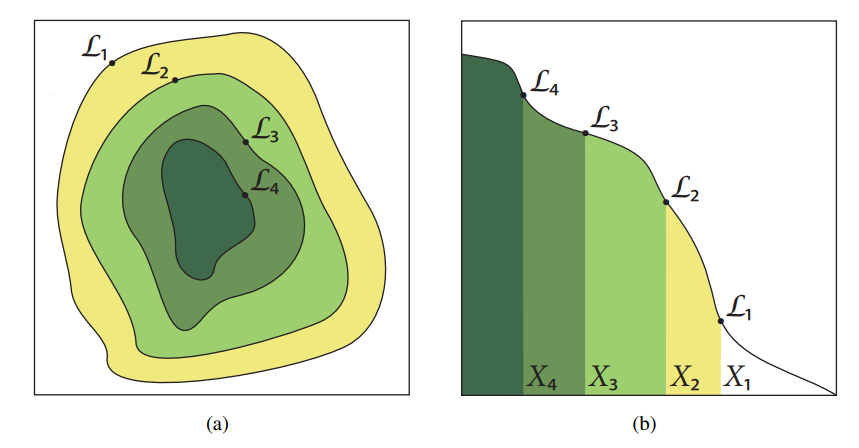


*Fig. 1. Cartoon illustrating (a) the posterior of a two dimensional problem; and (b) the transformed L(X) function where the prior volumes, $X_i$, are associated with each likelihood $L_i$*

*Taken from Feroz et al. (2019)*

### Basic Algorithm

  

The algorithm for Nested Sampling goes as follows:

1. Initialize volume $ X_0 =  1$ and integral $Z =  0$
2. Sample $N_{live}$ "live" points from the prior
---
3. At each iteration $i$:
      1. Find the point with lowest likelihood $L_i$
      2. Replace it with a new live point sampled from the prior subject to the constaint $L > L_i$
      3. Set the prior volume of the previous live point ("dead" point):
      \begin{equation}
      X_i ≈ \exp(-i/N_{live})
      \end{equation}
        *for derivation see for example Feroz et al. (2019)*
4. until stopping criteria are reached
---

5. The evidence integral can be numerically approximated using a set of $K$
 dead points via
 \begin{equation}
  Z = \int_0^1 L(X)dX ≈ ∑_{i=1}^K f(L_i)ΔX_i = ∑_{i=1}^Kω_i
 \end{equation}

  where $ω_i$ is each point's estimated weight.

  For a simple linear integration scheme using rectangles, one can take $f(L_i) =L_i$ and $ΔX_i = X_{i-1} - X_{i}$

  For a quadratic integration scheme using trapezoids (as used in $\textbf{dynesty}$), one instead can take $f(L_i) = (L_{i-1}+L_{i})/2$


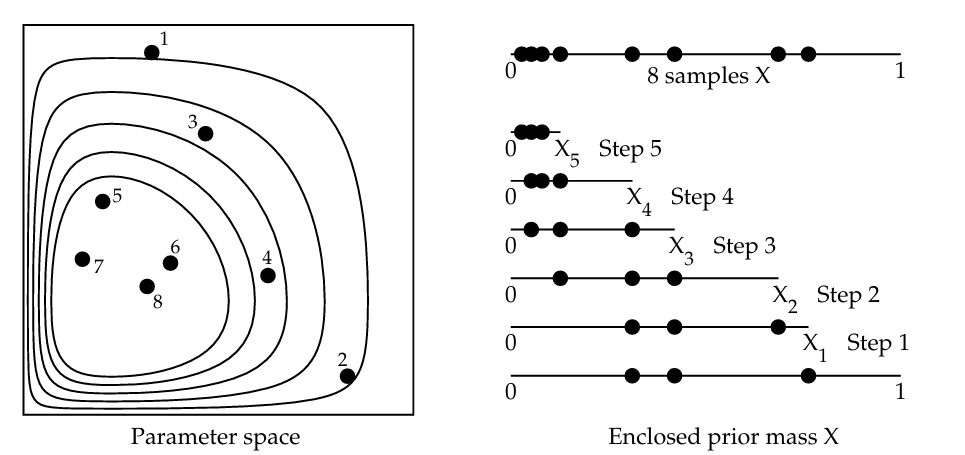

*Fig. 2. Nested sampling algorithm for five steps with a collection of three points. Evolution of the points: 1,3,4 → 2,3,4 → 3,4,5 → 4,5,6 → 5,6,7 →6,7,8*

*Taken from Skilling 2006*

#### Stopping criteria ##

   Since the remainig evidence $\Delta Z_i$ at iteration $i$ can be estimated:
  \begin{equation}
  \Delta Z_i ≈ L_{max}X_i
  \end{equation}
  where $L_{max}$ is the the maximum likelihood point contained within the remaining set of live points
  
This can be turned into a relative stopping criterion by using the log-ratio between the current estimated evidence $Z_i$ and the remaining evidence $ΔZ_i$:

\begin{equation}
Δln(Z_i) ≡ ln(Z_i +ΔZ_i) - ln(Z_i)
\end{equation}

Stopping at a given $Δln(Z_i)$ then means sampling until only a fraction of the evidence remains unaccounted for.

### Posterior Estimation


We can subsequently estimate posteriors “for free” from the same
 dead points by assigning each sample its associated importance weight

\begin{equation}
P(\textbf{Θ}_i) = \frac{ω_i}{Z}
\end{equation}

### Effective sampling

Nested Sampling (NS) progresses by replacing live points by independent samples drawn from the constrained prior, that is the prior restricted to regions in which the likelihood exceeds a threshold. This is the major difficulty in efficiently and reliably implementing NS, especially in multi-modal problems.

Whilst we could simply sample from the entire prior until we find a sample for which the likelihood exceeds the threshold, this rapidly becomes incredibly inefficient due to the exponential reduction in the volume contained within the constrained prior at every iteration. Fortunately, the current set of livepoints and the estimate of the volume enclosed by the contour may guide our search for new livepoints.

There are two main classes of methods for sampling from theconstrained prior:

*   Region Samplers
*   Step Samplers




#### Region Samplers

 In region sampling, we try to construct a region that bounds the iso-likelihood contour defined by the threshold. To find the region, we construct a geometric shape around the current distribution of live points. The shape must contain at least the currently estimated volume. We then draw independent and identically distributed (iid) samples from within that region until we obtain a sample that passes the current likelihood threshold.

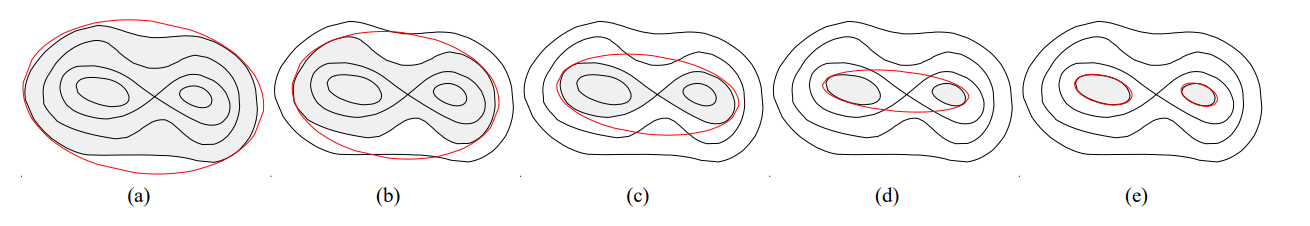

*Fig 3. Cartoon of ellipsoidal nested sampling from a simple bimodal distribution. In (a) we see that the ellipsoid represents a good bound to the active region. In (b)-(d), as we nest inward we can see that the acceptance rate will rapidly decrease as the bound steadily worsens. Figure (e) illustrates the increase in efficiency obtained by sampling from each clustered region separately.*

*Taken from Feroz et al. (2009)*

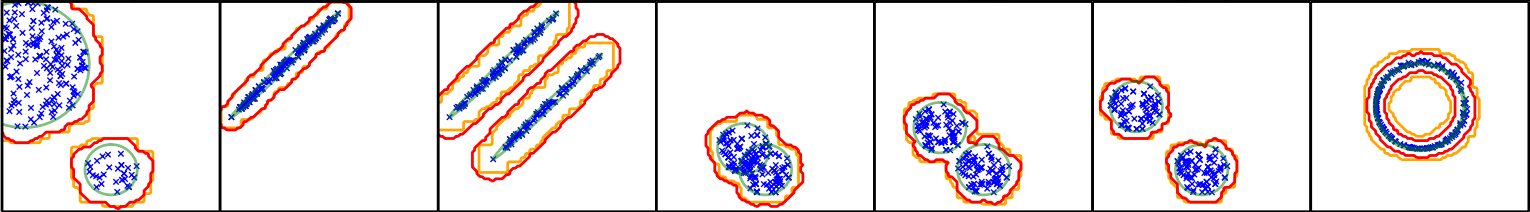

*Fig 4. Examples of sampled regions.*

*Taken from Buchner (2014)*


Region samplers are efficient and practical only for moderate-to-low dimensionality (D $\leq$ 20). (See Ashton et al. (2022))

#### Step Samplers

Step samplers, by contrast, do not attempt to construct a region that bounds the iso-likelihood contour. Instead, they evolve by randomly choosing existing live point through a sequence of steps to a new approximately independent position (by use of well-known MCMC methods).

The rule is simply that we accept a transition if
\begin{equation}
L(\textbf{Θ}) > L^*
\end{equation}

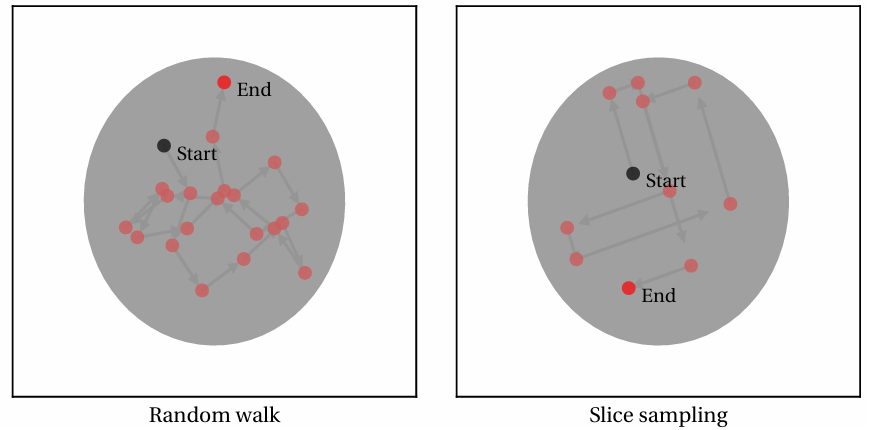

*Fig. 5. Examples of step sampling.*

*Taken from Ashton et al. (2022)*

# [Dynesty](https://https://dynesty.readthedocs.io/en/stable/index.html)

`dynesty` is a Pure Python, MIT-licensed Dynamic Nested Sampling package for estimating Bayesian posteriors and evidences.

`dynesty` is compatible with Python 3.6+. It requires `numpy` (for arithmetic), `scipy` (for special functions), `matplotlib` (for plotting), and while not required, `tqdm` also allows for a nice progress bar.

For installing the most recent stable version of the package is simply use:


In [1]:
pip install dynesty

Note: you may need to restart the kernel to use updated packages.


## Excercises


We will start with a simple example, calculating the integral:


\begin{equation}
Z = \frac{1}{(2a)^2}\int_{-a}^{a}\int_{-a}^{a}e^{-x^2 -y^2} dx dy
\end{equation}

$ln Z ≈ -3.46$ for $a = 5 $ ( *Ashton et al., 2022* )

### Prior transform

The prior transform function is used to implicitly specify the Bayesian prior $π(\textbf{Θ})$ for Nested Sampling. It functions as a transformation from a space where variables are uniformly distributed from 0 to 1 within the $D$-dimensional unit cube (i.e. $U(0,1)^D$ ) to the parameter space of interest.

Suppose we want our prior to be the following:

*   The first variable is uniform from [-10,10)
*   The second variable is uniform from [-1,4)

So we have to transform $U(0,1)^2 → [U(-10,10), U(-1,3)]$

In [2]:
def prior_transform_example(u):



    x = np.array(u) #copy u

    ### first variable ###
    x[0] = x[0]*20 # ~Uniform[0, 20)
    x[0] = x[0]-10 # ~Uniform[-10,10)

    ### second variable ###
    x[1] = x[1]*4 # ~Uniform[0, 4)
    x[1] = x[1]-1 # ~Uniform[-1,3)

    return  x


For our integral we want our prior to be Uniform from $[-a,a)$ for both axis. For example let $a=5$.

We have to transform the unit hypercube $U(0,1)^2$ to $U(-a,a)^2$ 

**Excercise:** Try doing it yourself


In [3]:
def prior_transform(u):

    '''YOUR CODE HERE'''

    return  '''your output'''

**Solution**

In [4]:
def prior_transform(u):
    a = 5
    return 2*a*u -a

### Likelihood

In our example, the "likelihood" has a form of:

\begin{equation}
L(x,y) = e^{-x^2 - y^2}
\end{equation}

For running dynesty we have to construct loglikelihood (`loglike`), which is just a logarithm of the likelihood.

**Excercise:** Construct the likelihood function yourself:

In [5]:
import numpy as np

''' define the log likelihood function '''
''' input: theta - vector of parameters. In this example theta = [x,y]'''

def loglike(theta):

    '''YOUR CODE HERE'''

    return

**Solution**

In [6]:
import numpy as np

''' define the log likelihood function '''
''' input: theta - vector of parameters. In this example theta = [x,y]'''

def loglike(theta):

    return -(theta**2).sum()

### Performing Nested Sampling Inference with "dynesty"

Nested Sampling in dynesty is done via a high-level `sampler` object.

To start, let’s use `NestedSampler()` to initialize a particular sampler from `nestedsamplers`. There are only 3 required arguments: a log-likelihood function (`loglike`), a prior transform function (`ptform`), and the number of dimensions taken by the loglikelihood (`ndim`).

As long as you have access to a likelihood function, nested sampling can be used quite 'black-boxy'. It does not require much tuning and does not require knowledge of the underlying mechanisms, although it is obviously good to knwo what you are doing. In this example, hyperparameters such as the number of livepoints or the stopping criterion are automatically determined by dynesty.

Using the functions above, we can initialize our sampler using:

In [7]:
import dynesty


# additionally you can seed the random number generator for reproducibility
rstate = np.random.default_rng(123)

#initialize sampler
sampler = dynesty.NestedSampler(loglike, prior_transform, ndim=2, rstate = rstate)

Sampling from our target distribution can be done using the `run_nested()` function in the provided sampler:

In [8]:
#start the run
sampler.run_nested()

2134it [00:00, 3125.90it/s, +500 | bound: 1 | nc: 1 | ncall: 18687 | eff(%): 14.483 | loglstar:   -inf < -0.000 <    inf | logz: -3.426 +/-  0.070 | dlogz:  0.001 >  0.509]


Sampling results can be accessed through the `results` property and are returned as a (modified) dictionary:

In [9]:
#get results
results  = sampler.results

We can print a quick summary of the run using `summary()`, which provides basic information about the evidence estimates and overall sampling efficiency:

In [10]:
results.summary()

Summary
nlive: 500
niter: 2134
ncall: 18187
eff(%): 14.483
logz: -3.426 +/-  0.139


Describtion of the quantities:


*   nlive: the number of livepoints used in the run
*   niter: the number of iterations (samples)
*   ncall: the total number of likelihood calls. **Q: Do you understand why this number is higher than niter?**
*   eff(%): the overall samping efficiency
*   logz: the cumulative log-evidence



Let's compare NestedSampler results with the usual numeric integration. Here we use `dblquad` from `scipy`

In [11]:
from scipy import integrate

scipy's integrate works by calling

`result = integrate.dblquad(func, bound_low_variable1,bound_high_variable1, bound_low_variable2,bound_high_variable2)`
                  
**Excercise:** Try it yourself. Determine the integral of our example function and compare the result with the nested sampling output.

In [13]:
'''YOUR CODE HERE'''

'YOUR CODE HERE'

**Solution**

In [12]:
# collect result and error from dynsesty
dynesty_res  = [results.logz[-1], results.logzerr[-1]]

######### compute the result with scipy ##########
from scipy import integrate

a = 5

#define the function for our integral example
def func(y,x):
    return 1/(2*a)**2*np.exp(-x**2-y**2)

#retrun value of the integral and the error
scipy_res = integrate.dblquad(func,-a,a,-a,a)

#transform tresult to log
def reults_to_log(p):
    return [np.log(p[0]), p[1]/p[0]]

scipy_res = reults_to_log(scipy_res)

###################################


###compare the results###
print('dynesty result: ', dynesty_res[0], '+/-', dynesty_res[1])
print('scipy result: ', scipy_res[0], '+/-', scipy_res[1])




dynesty result:  -3.4257245990365504 +/- 0.1394416351610944
scipy result:  -3.4604403001417605 +/- 4.236284939002642e-07


#### Live Points

The behavior of Nested Sampling is sensitive to the number of live points used. Along with the sampling rule, this is the main hyperparameter for tuning your nested sampling runs. Increasing the number of live points leads to smaller changes in the prior volume  $ln X$ over time. This improves the effective resolution while simultaneously increasing the runtime.


It is important to note that running with too few live points can lead to mode “die off”. When there are multiple modes with live points distributed between them, live points can randomly “jump” between them at any given iteration. If there are only a handful of live points at a particular mode, it is possible that, entirely by chance, all of them could transfer completely to the other mode even as both remain equally likely, leading it to “die off” and likely never be located again. As a rule-of-thumb, you should allocate around 50 live points per possible mode to guard against this.

The number of live points can be specified upon initialization via the `nlive` argument. For example, if we want to run with 1000 live points we would use:

`NestedSampler(loglike, ptform, ndim, nlive=1000)`


**Excercise:** Perform Nested Sampling with 1000 livepoints for our integral example. Do you notice differences during the run? Does the result change?

In [13]:
'''YOUR CODE HERE'''

'YOUR CODE HERE'

**Solution**

In [14]:
''' Constructing, running and obtaining the resutls for samplers with 1000 live points'''

sampler_1000 = dynesty.NestedSampler(loglike, prior_transform, ndim=2, nlive=1000, rstate =rstate)
sampler_1000.run_nested()
results_1000 = sampler_1000.results
print(results_1000.summary())

3724it [00:01, 2954.45it/s, +1000 | bound: 1 | nc: 1 | ncall: 37107 | eff(%): 13.083 | loglstar:   -inf < -0.000 <    inf | logz: -3.495 +/-  0.050 | dlogz:  0.001 >  1.009]

Summary
nlive: 1000
niter: 3724
ncall: 36107
eff(%): 13.083
logz: -3.495 +/-  0.133
None


### Stopping criteria

Sampling will continue until specified stopping criteria are reached, and the current state of the sampler is by default output to `stderr` in real time. The stopping criteria can be any combination of:



*   a fixed number of iterations (`maxiter`)
*   a fixed number of likelihood calls (`maxcall`)
*   a maximum likelihood (`logl_max`)
*   a pecified $ΔZ_i$ tolerance (`dlogz`)
*   a specified Effective Sample Size (`n_effective`)


These can be an input for `run_nested()` function do get something like:



In [15]:
sampler_dlog = dynesty.NestedSampler(loglike, prior_transform, ndim=2, rstate =rstate)
sampler_dlog.run_nested(dlogz = 10, maxiter = 10000, maxcall = 50000)
results_dlog = sampler_dlog.results
print(results_dlog.summary())

640it [00:00, 5802.50it/s, +500 | bound: 0 | nc: 1 | ncall: 2414 | eff(%): 59.561 | loglstar:   -inf < -0.001 <    inf | logz: -3.479 +/-  0.092 | dlogz:  0.018 > 10.000]

Summary
nlive: 500
niter: 640
ncall: 1914
eff(%): 59.561
logz: -3.479 +/-  0.441
None


### Visualizing results


Dynesty comes with a variety of built-in plotting utilities in the `plotting` module. These include a variety of generic summary plots as well as ways of visualizing bounding distributions throughout the course of a run. We can import them using:

In [16]:
from dynesty import plotting as dyplot

#### Summary plots

One of the most direct ways of visualizing how Nested Sampling computes the evidence is by examining the relationship between the prior volume $ln X $
 and:

1.   the (effective) iteration, which illustrates how quickly/slowly our samples are compressing the prior volume
2.   the likelihood $L_i$, to see how smoothly we sample “up” the likelihood distribution to the maximum likelihood (ML) estimate,
3. the importance weight $p_i = \frac{ω_i}{Z}$, showcasing where the bulk of the posterior mass is located
4. the evidence $Z_i$ , to see where most of the contribution to the evidence (and its respective errors) are coming from.


A summary (run) plot showcasing these features can be generated using `runplot()`. As an example, a summary plot for 3 of our samplers will be ploted.

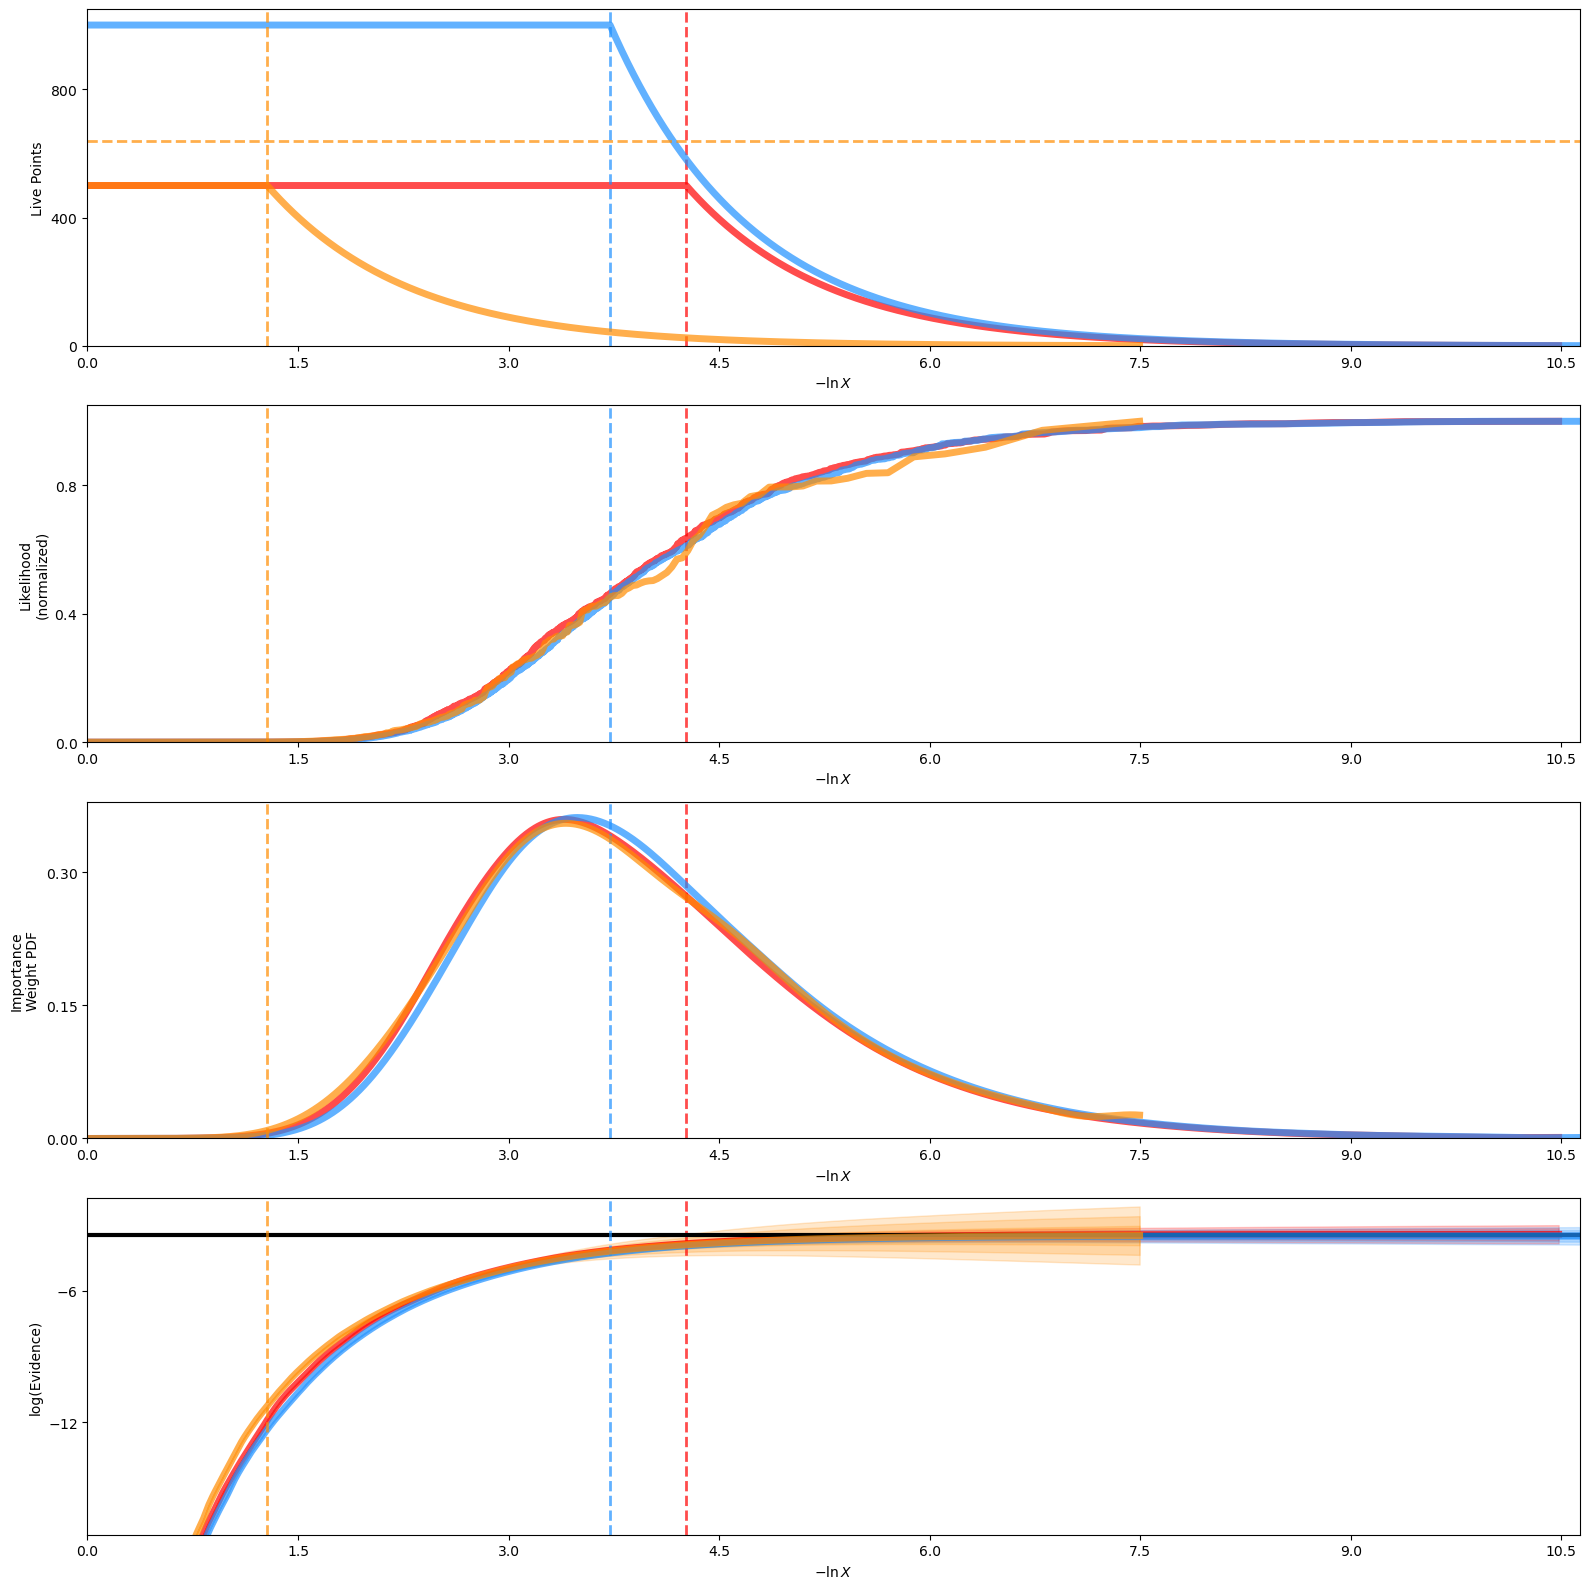

In [17]:
lnz_truth = scipy_res[0] # solution from scipy

fig, axes = dyplot.runplot(results, color='red', logplot=True, lnz_truth=lnz_truth, truth_color='black')
fig, axes = dyplot.runplot(results_1000, color='dodgerblue', logplot=True, fig=(fig, axes))
fig, axes = dyplot.runplot(results_dlog, color='darkorange', logplot=True, fig=(fig, axes))
fig.tight_layout()


**Excercise:** Make sure you understand the information in those plots. In case you run into trouble while applying nested sampling to your own problems these serve as a quick diagnostic of potential problems.

#### Traces and Posteriors

Another common way to visualize the results of many sampling algorithms is to generate a trace plot showing the evolution of particles (and their marginal posterior distributions) in 1-D projections. This can be done using the `traceplot()` function, which plots a combination of particle positions as a function of $ln(X)$
 (colored by importance weight) and the corresponding 1-D marginalized posterior:

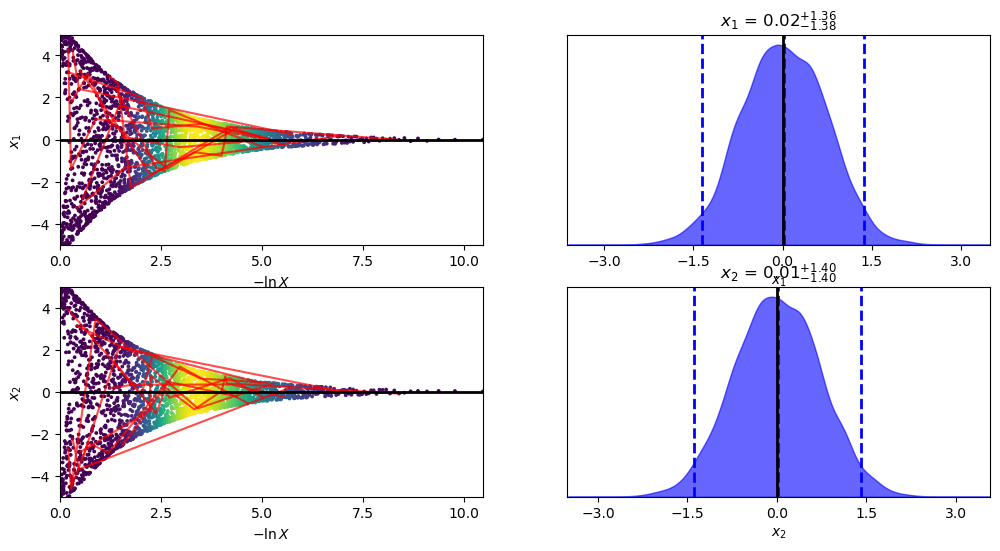

In [18]:
fig, axes = dyplot.traceplot(results, truths=np.zeros(2),
                             truth_color='black', show_titles=True,
                             trace_cmap='viridis', connect=True,
                             connect_highlight=range(10))



We can get a better qualitative and quantitative handle on this by plotting the marginal 1-D and 2-D posterior density estimates using `cornerplot()` as:

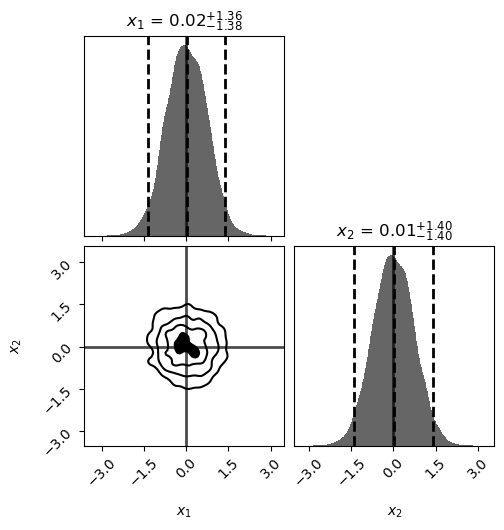

In [19]:
fg, axs = dyplot.cornerplot(results,truths=np.zeros(2), truth_color='black', show_titles=True )

### Doing science I: Understanding parameter estimation and posterior generation

The dashed lines in the plots above indicate the "credible interval". It is the region where the "true" parameter lies with 95% probability according to the estimated posterior distribution $p(\Theta| D, M)$. After parameter estimation, this is the result you should put in your paper: The mean/median/maximum-posterior parameter + the estimated error given by the credible interval. It is instructive to construct this credible interval yourself.

You can access samples and weights directly using the `results` object and call results.samples and results.importance_weights()

**Excercise:** Visualize the samples in a scatter plot and compute the marginal densities

**Solution:**

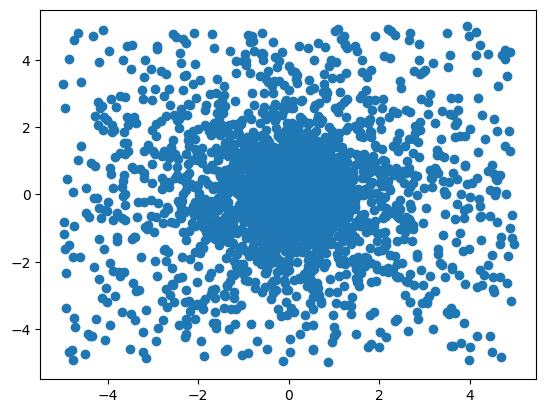

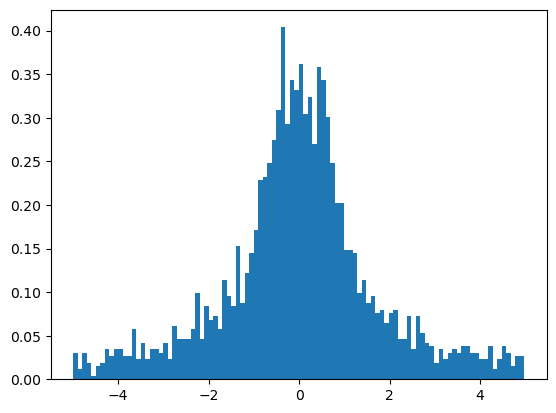

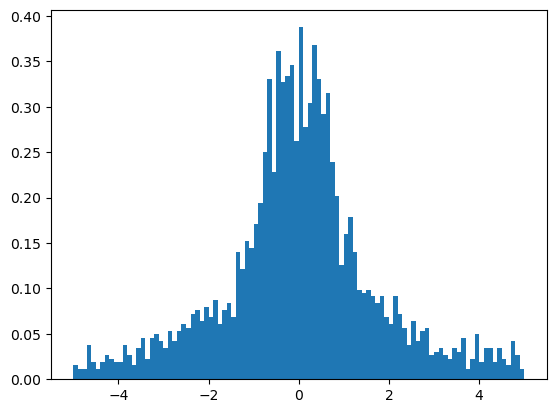

In [20]:
import matplotlib.pyplot as plt
plt.scatter(results.samples[:,0], results.samples[:,1])
plt.show()

plt.hist(results.samples[:,0], bins=100, density=True)
plt.show()
plt.hist(results.samples[:,1], bins=100, density=True)
plt.show()


These are not the posterior distributions yet! Each sample has to be weighted accordingly. Lets do this using `results.importance_weights()`

**Excercise:** Obtain the correctly weighted marginal posterior distributions. From those compute the 95% credible interval for both parameters as the 0.025 and 0.975 quantiles of the posterior distribution. 

**Hint:** Its easy to obtain the quantiles when the samples are sorted and plotted against the cumulative weight until this sample. If the cumulative weights are normalized to 1 as the highest values, this is also called a cumulative distribution. For example the 0.25-quantile then starts exactly where the cumulative distribution has the value 0.25! Visualize this first by plotting the cumulative distribution.

To sort samples you can use `np.argsort()` to obtain sorted indices or `np.sort()` to obtain sorted values. To compute cumulative sums of a vector use numpy's `np.cumsum()`. To find the value of the quantiles use numpy interpolation function `np.interp(quantile, cumulative_distribution, sorted_samples)`.


In [21]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

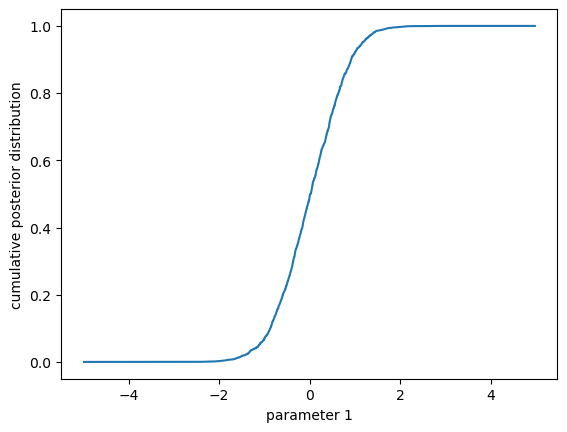

In [22]:
# lets take the samples of parameter 1
samp = results.samples[:,0]

# sort samples
samples_sorted = np.sort(samp) 
idx_sorted = np.argsort(samp)  

# get corresponding weights
weights = results.importance_weights()
sw = weights[idx_sorted]

# cumulative distribution (results.importance_weights() are already normalized!!)
cumsw = np.cumsum(sw)

# plot the cumulative distribution
plt.plot(samples_sorted, cumsw)
plt.ylabel('cumulative posterior distribution')
plt.xlabel('parameter 1')
plt.show()

In [23]:
# obtaining the desired quantiles can be done by simply taking the respective value in the samples_sorted list

# get number of samples
Nsamp = len(samples_sorted)

# define quantiles
quants = np.array([0.025, 0.5, 0.975])

# get the values at the corresponding indices
low, mid, high = np.interp(quants, cumsw, samples_sorted).tolist()

print('the credible interval ranges from {} to {} with the most likely parameter value being {}.'.format(low, high, mid))

the credible interval ranges from -1.3596853366156167 to 1.3709512396366879 with the most likely parameter value being 0.01614732913218439.


Dynesty also has a function that computes quantiles. 

**Excercise:** Check your result using dynesty's quantile function. It takes the following inputs and outputs: 

parameter_values_for_each_quantile = quantile(samples, quantiles, importance weights)

In [24]:
from dynesty.utils import quantile

In [27]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

In [25]:
low, mid, high = quantile(results.samples[:,0], [0.025, 0.5, 0.975], weights=results.importance_weights())
print('the credible interval ranges from {} to {} with the most likely parameter value being {}.'.format(low, high, mid))

the credible interval ranges from -1.357184475975433 to 1.3733733562012738 with the most likely parameter value being 0.017996660771489443.


# Congratulations: 
You now know the most important basics. How to perform nested sampling, how to obtain the evidence, how to visualize results and how to obtain posterior estimates and credible intervals for parameter estimation. Lets now look at some advanced options.

### Effective Sampling

As was already discussed, it is important to sample the live points efficiently from the constrained prior via region sampers and/or step samplers.

Let's see what `dynesty` offers us for sampling options.

Construct a bit more complicated likelihood:

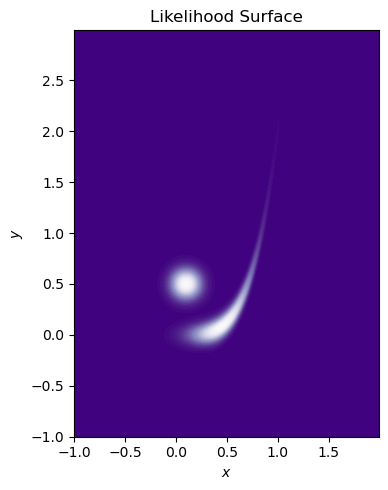

In [26]:
import matplotlib.pyplot as plt

def bananalike(x,y):
    return np.exp(-(7*(0.45-x))**2/4 - (20*(y/2-x**4))**2)

def Gauss(x,y):
    return np.exp(-(x-0.1)**2/(2*0.1**2) - (y-0.5)**2/(2*0.1**2))

def complexlike(x,y):
    return bananalike(x,y) + Gauss(x,y)



# plot the likelihood surface
plt.figure(figsize=(5., 5.))
axes = plt.axes(aspect=1)

x = np.arange(-1,2,0.01)
y = np.arange(-1,3,0.01)

X,Y = np.meshgrid(x,y)
L = complexlike(X, Y)


axes.contourf(X, Y, L, 50, cmap=plt.cm.Purples_r)
plt.title('Likelihood Surface')
plt.xlabel(r'$x$')
plt.ylabel(r'$y$')

plt.tight_layout()
plt.show()



#### Default run

**Excercise:** Perform the usual nested sampling using the likelihood and prior given below. Use 500 livepoints. Plot the result using dynesty's cornerplot routine.

In [27]:
def prior(u):
    return u*np.array([3,4]) + np.array([-1,-1])

def loglike(p):
    return np.log(complexlike(p[0],p[1]))


In [31]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

2618it [00:01, 1896.20it/s, +500 | bound: 3 | nc: 1 | ncall: 20806 | eff(%): 15.355 | loglstar:   -inf < -0.001 <    inf | logz: -4.389 +/-  0.082 | dlogz:  0.001 >  0.509]


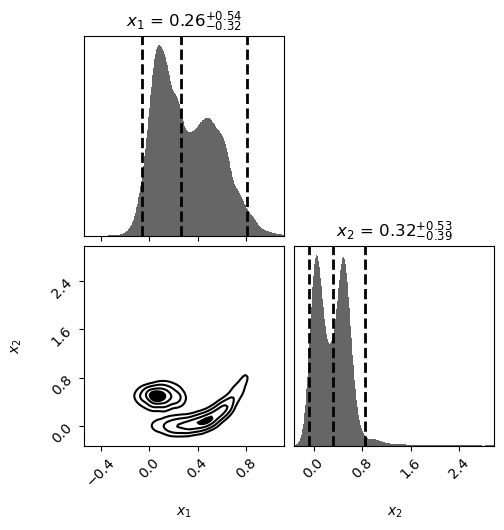

In [28]:
sampler_region = dynesty.NestedSampler(loglike, prior, ndim = 2, nlive = 500, rstate=rstate)
sampler_region.run_nested()
results_region = sampler.results

from dynesty import plotting as dyplot

dyplot.cornerplot(sampler_region.results, show_titles= True);

#### Bounding options

There are five bounding methods that are implemented in `dynesty`:


*   no bounds `'none'`
*   a single ellipsoid `'single'`
*   multiple ellipsoids `'multi'`
*   many overlapping balls `'balls'`
*   many overlapping cubes `'cubes'`

Let's test them and get a feeling for the runtime of the run.

**Excercise:** For each of the bound options above, perform a nested sampling run and measure the time it takes. You can pass the bound in the NestedSampler object like this: `dynesty.NestedSampler(loglike, prior, ndim = 2, nlive = 500, bound = bound, rstate =rstate)`. You can record the system time via the time module and calling time.time() before and after the run

In [29]:
import time

In [34]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

In [30]:
# bounding methods
bounds = ['none','single', 'multi', 'balls','cubes']

# bounding results
res_bounds = []

for bound in bounds:

    print('Bound:', bound)
    sampler_bounds = dynesty.NestedSampler(loglike, prior, ndim = 2, nlive = 500, bound = bound, rstate =rstate)

    start_time = time.time()
    sampler_bounds.run_nested()
    end_time = time.time()
    print('\nTime: ', end_time - start_time,'\n')

    res_bounds.append(sampler_bounds.results)



Bound: none


2618it [00:01, 1578.32it/s, +500 | bound: 1 | nc: 1 | ncall: 90585 | eff(%):  3.461 | loglstar:   -inf < -0.000 <    inf | logz: -4.388 +/-  0.082 | dlogz:  0.001 >  0.509]



Time:  1.6604969501495361 

Bound: single


2626it [00:00, 3484.73it/s, +500 | bound: 12 | nc: 1 | ncall: 27143 | eff(%): 11.733 | loglstar:   -inf < -0.001 <    inf | logz: -4.413 +/-  0.083 | dlogz:  0.001 >  0.509]



Time:  0.7548680305480957 

Bound: multi


...


Time:  1.197005033493042 

Bound: balls


2548it [00:03, 810.45it/s, +500 | bound: 3 | nc: 1 | ncall: 19710 | eff(%): 15.867 | loglstar:   -inf < -0.000 <    inf | logz: -4.245 +/-  0.080 | dlogz:  0.001 >  0.509]



Time:  3.1453561782836914 

Bound: cubes


2624it [00:01, 1771.79it/s, +500 | bound: 3 | nc: 1 | ncall: 20215 | eff(%): 15.846 | loglstar:   -inf < -0.000 <    inf | logz: -4.404 +/-  0.083 | dlogz:  0.001 >  0.509]


Time:  1.4821240901947021 



As you can see, choosing a bounding procedure in lower dimensions only marginally improves the runtime or even increases it for certain bound choices. This however, will dramatically change for problems in higher dimesions.

**Homework (or do it now if you want to):** Construct a high dimensional likelihood and repeat the evaluation above.

Using `cornerbound()`, we can examine the evolution of the bounding distributions

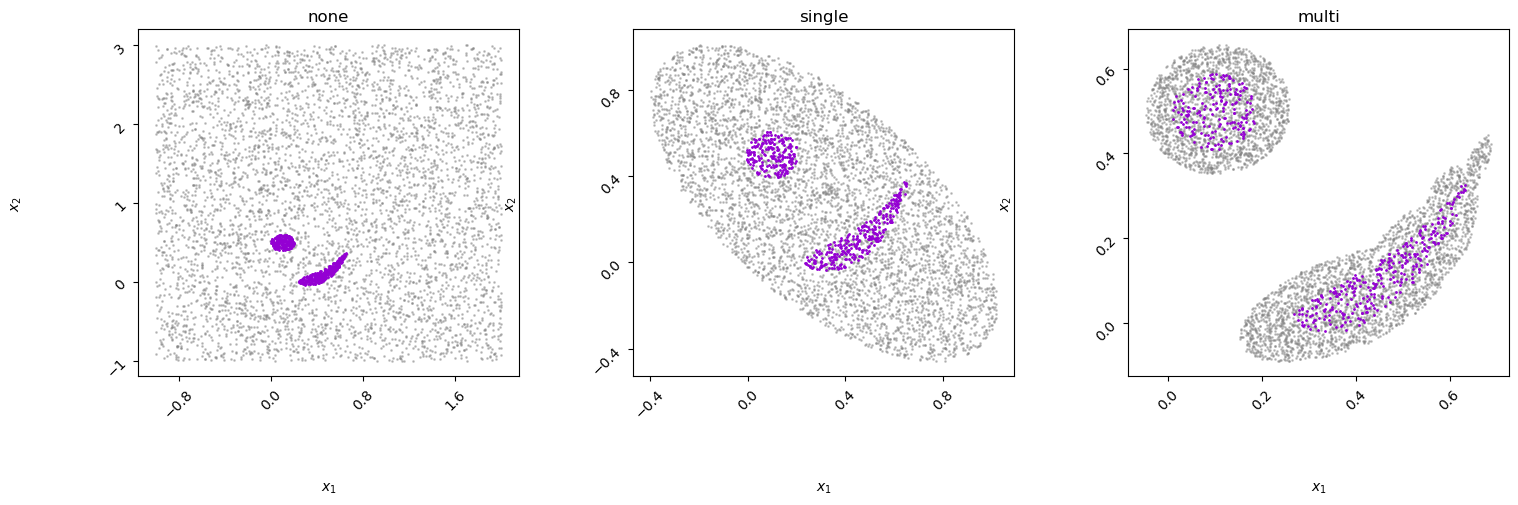

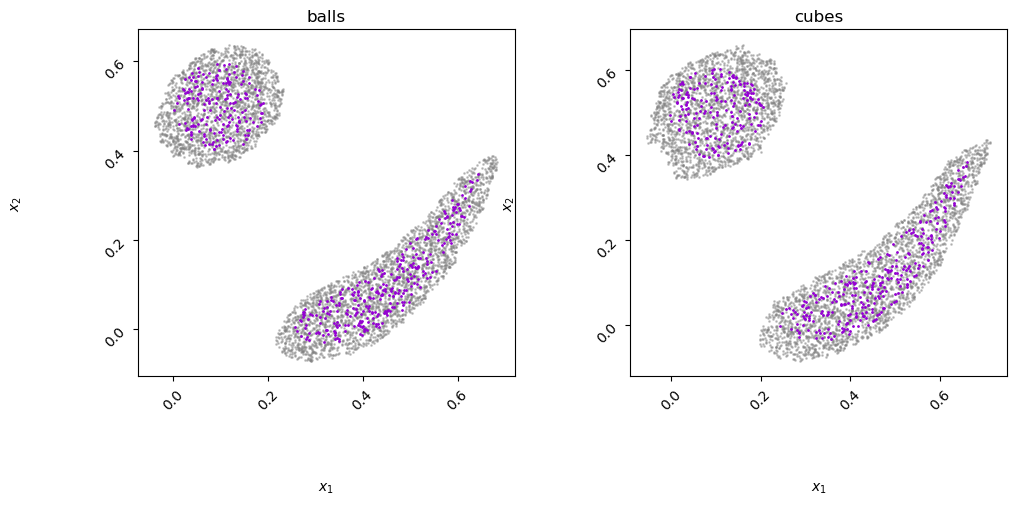

In [31]:
#initial figure
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# plot 'none', 'single', 'multi'
for i in range(3):

    fg, ax = dyplot.cornerbound(res_bounds[i], it = 2500, prior_transform=prior, show_live=True, fig= (fig,axes[i]))
    axes[i].set_title(bounds[i])

fig.tight_layout()


#initial figure
fig, axes = plt.subplots(1, 2, figsize=(10, 5))

# plot  'balls' and 'cubes'
for i in range(2):

    fg, ax = dyplot.cornerbound(res_bounds[3+i], it = 2500, prior_transform=prior, show_live=True, fig= (fig,axes[i]))
    axes[i].set_title(bounds[3+i])


fig.tight_layout()



#### Sampling Options

Once a bounding distribution has been constructed, dynesty
 generates samples conditioned on those bounds via `sample` argument

`dynesty` implements four main approaches to generat
ing samples:



*   uniform sampling (`unif`)
*   random walk (`rwalk`)
*   multivariate slice sampling away from a current live point (`slice`)
*   random slice sampling away from a current live point (`rslise`)
*   “Hamiltonian” slice sampling away from a current live point (`hslice`)




By default, dynesty automatically picks a sampling method based on the dimensionality of the problem via the `auto` argument, which uses the following logic:

If

*   If $ D \lt 10$, `unif` is chosen since uniform proposals can be quite efficient in low dimensions

*   If $\leq D \leq 20$, `rwalk` is chosen since random walks are more robust to underestimated bounding distributions in higher dimensions

*   If  $D \gt 20$ and a gradient is not provided, `rslice` is chosen since non-rejection sampling methods scale in polynomial (rather than exponential) time as the dimensionality increases.

*   If $D \gt 20$ and a gradient is provided, `hslice` is chosen to take advantage of Hamiltonian dynamics, which scale better than `rslice` as the dimensionality increases

Note that `hslice`, while using gradients, is substantially less efficient (and in general less reliable) than other gradient-based approaches such as Hamiltonian Monte Carlo. As such, use them at your own risk.

# Toy example for parameter estimation and model comparison

Now you know the most important functions of Nested Sampling and are well prepared to test your newly acquired skills on a first toy example. You will perform parameter inference and model comparison using nested sampling on a simple noisy sine function.

Consider we have a data according to the sinusoidal function:

\begin{equation}
y = A\sin(ω_0x +\phi_0) +B
\end{equation}

Here the parameters are:


*   $A$ - the amplitude
*   $ω_0$ - frequency
*   $ϕ_0$ - phase
*   $B$ - offset



Construct the model:

In [32]:
def sine_model(x, A, B, omega_0, phi_0):
    return A * np.sin(x * omega_0 + phi_0) + B

Lets first create some noisy data and plot it

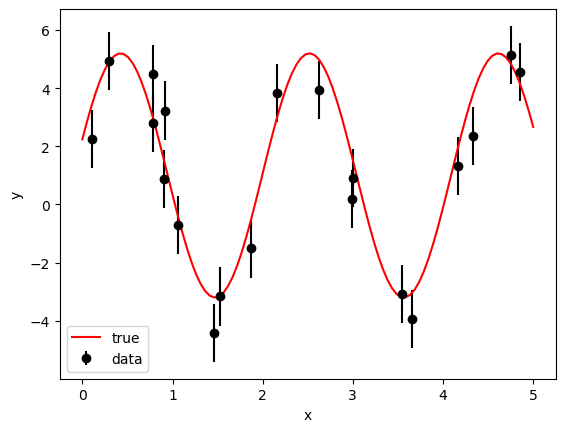

In [34]:
#true values
A_true = 4.2
B_true = 1.0
omega_0_true = 3
phi_0_true = 0.3


#create noisy data
np.random.seed(42)

N_data = 20
x = np.random.uniform(0, 5, size=N_data) # draw data uniformly (we are not using equidistant points here)
y_true = sine_model(x, A=A_true, B=B_true, omega_0=omega_0_true, phi_0=phi_0_true) # true values for y

# measurement values
yerr = 1.0 #std of y
y = np.random.normal(y_true , yerr**2) # 'measure' data with the noise

# plot the 'measured' data
plt.figure()
plt.xlabel('x')
plt.ylabel('y')
plt.errorbar(x=x, y=y, yerr=yerr,
             marker='o', ls=' ', color='black', label ='data');

# plot true curve
x_plot = np.linspace(0,5, 100)
y_plot = sine_model(x_plot, A=A_true, B=B_true, omega_0=omega_0_true, phi_0=phi_0_true)
plt.plot(x_plot, y_plot, color='red', label='true')

plt.legend()
plt.show()




Now its time to prepare for the nested sampling run.

**Excercise:** Come up with a suitable loglike and a prior function. This is where your "statistical modelling" skills are needed. Nested Sampling will do the rest.

**For a hint, click on the (click me) below**
<details>
  <summary>(click me)</summary>
   
   The likelihood measures how far the data are from the model predictions. As a simple cost function we can assume gaussian measurement errors of known size (yerr).
</details>

**For another hint, click on the (click me 2)**
<details>
  <summary>(click me 2)</summary>
   
   The likelihood can be constructed by so-called least squares, which is exactly assuming Gaussian measurement error

\begin{equation}
χ^2 = ∑\left( \frac{y_{model} - y_{true}}{\sigma_y} \right)^2
\end{equation}

\begin{equation}
ln L  = -χ^2/2
\end{equation}
</details>


In [39]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

In [35]:
'''parameters = ['A', 'B', 'omega_0', '$phi_0$'] '''

def loglike_sine(p):

    # unpack the current parameters:
    A = p[0]
    B = p[1]
    omega_0 = p[2]
    phi_0 = p[3]

    # compute y for each x point
    y_model = sine_model(x, A=A, B=B, omega_0=omega_0, phi_0=phi_0)

    # compute likelihood
    loglike = -0.5 * (((y_model - y) / yerr)**2).sum()

    return loglike


Define the parameter ranges through the prior:

In [36]:
'''parameters = ['A', 'B', 'omega_0', '$phi_0$']'''

def prior_sine(u):

    x = u #copu u

    x[0] = 10*x[0] # A from 0, to 10
    x[1] = x[1]*20 - 10 # B from -10 to 10
    x[2] = x[2]*10 # omega_0 from 0 to 10
    x[3] = x[3]*20 -10 #phi_0 from -10 to 10

    return x


**Excercise:** Run nested sampling and visualize the results.

In [42]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

Run the NestedSampler:

In [37]:
sampler_sine = dynesty.NestedSampler(loglike_sine, prior_sine, ndim=4, nlive =1000, rstate =rstate, sample ='rslice');
sampler_sine.run_nested(dlogz = 0.01);
results_sine = sampler_sine.results;

18554it [00:18, 1028.72it/s, +1000 | bound: 45 | nc: 1 | ncall: 662802 | eff(%):  2.955 | loglstar:   -inf < -6.975 <    inf | logz: -20.910 +/-  0.109 | dlogz:  0.000 >  0.010]


Visualize the results:

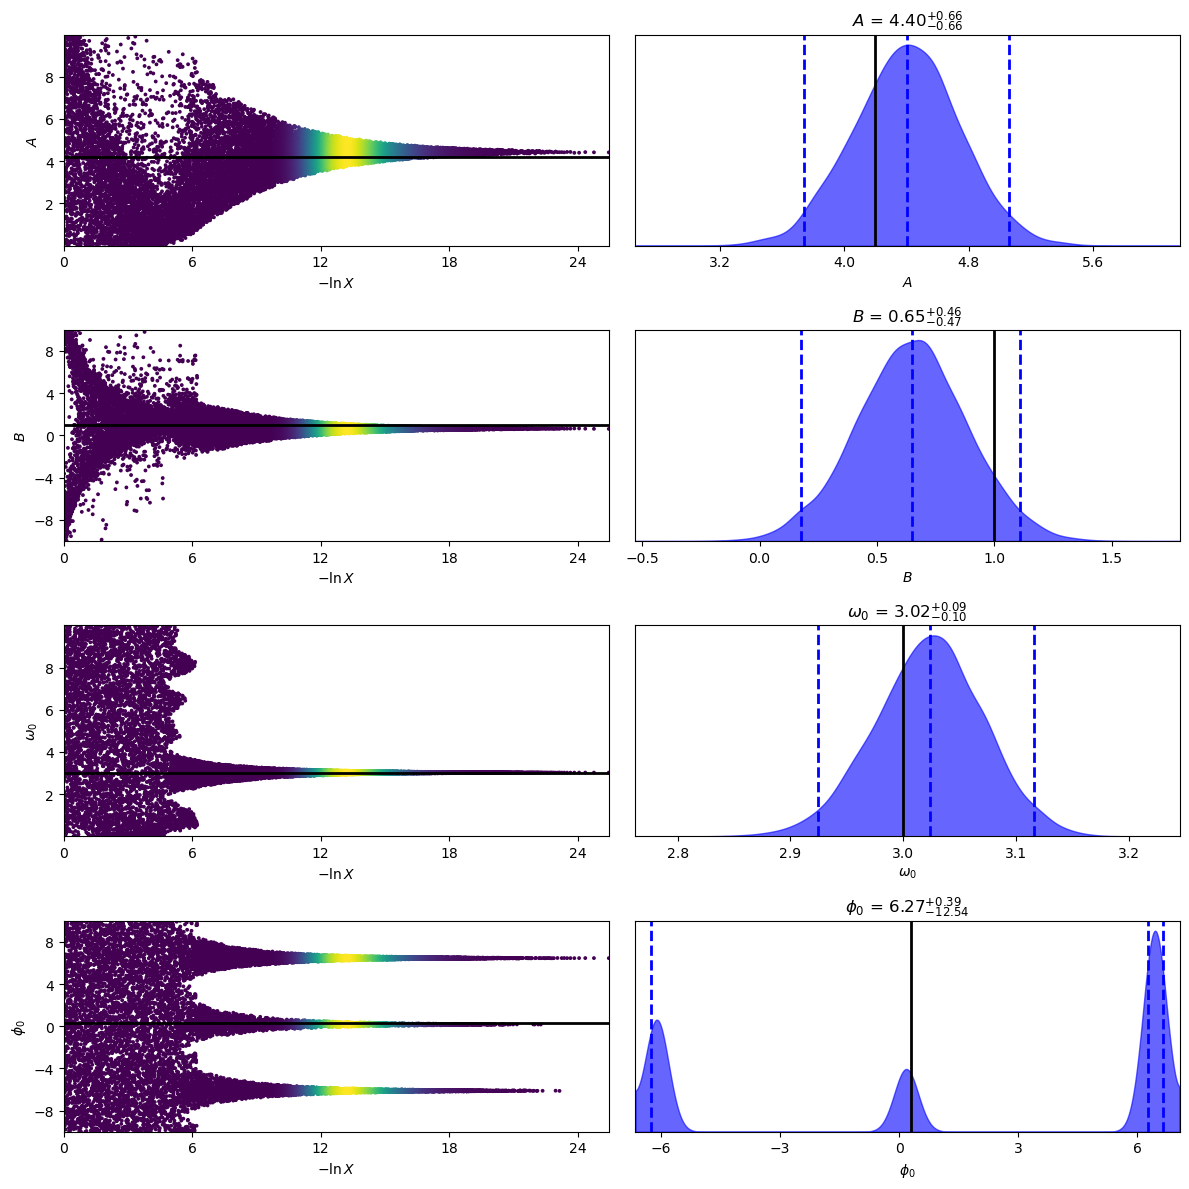

In [38]:
truths = np.array([A_true, B_true, omega_0_true, phi_0_true])
labels = [r'$A$', r'$B$', r'$\omega_0$', r'$\phi_0$']
fig,axes = dyplot.traceplot(results_sine, truths=truths,
                           truth_color='black', show_titles=True, trace_cmap='viridis', labels = labels)

plt.tight_layout()

### Doing Science II: Model Comparison

One of the greatest advantages of Nested Sampling is sampling the correct evidence. Let us compare the sine model with pure noise. No matter in what situation you do parameter inference, you should always make sure your model is at least better than purely random data as null-hypothesis. If your model does not beat a random model it is meaningless no matter how well it fits the data.

You can use the following prior and loglikelihood.

In [44]:
def sine_model_noise(x, B):
    return x*0 + B

def prior_sine_noise(u):
    x = u #copu u

    x[0] = 20*x[0] - 10 # B from -10, to 10
    
    return x

def loglike_sine_noise(p):
    
    # unpack the current parameters:
    B = p[0]
    
    # compute y for each x point
    y_model = sine_model_noise(x, B=B)
    
    # compute likelihood
    loglike = -0.5 * (((y_model - y) / yerr)**2).sum()

    return loglike

    

**Excercise:** Compute the evidence of the random model and calculate the Bayes factor, which is the ratio of the evidence of sine model vs random model. Which model is more likely?

In [46]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

In [45]:
sampler_sine_noise = dynesty.NestedSampler(loglike_sine_noise, prior_sine_noise, ndim = 1, rstate = rstate, bound = 'none')
sampler_sine_noise.run_nested(dlogz = 0.01)
results_sine_noise = sampler_sine_noise.results

4053it [00:28, 143.52it/s, +500 | bound: 1 | nc: 1 | ncall: 1640441 | eff(%):  0.278 | loglstar:   -inf < -91.277 <    inf | logz: -94.763 +/-  0.077 | dlogz:  0.000 >  0.010]


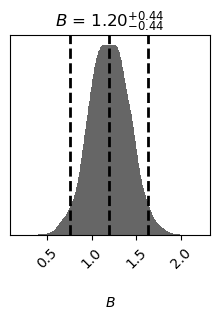

In [46]:
dyplot.cornerplot(results_sine_noise, show_titles= True, labels = [r'$B$']);


The Bayes factor is:

In [47]:
K = np.exp(results_sine.logz[-1] - results_sine_noise.logz[-1])
print("K = %.2f" % K)
print("The 1-sine model is %.2f times more probable than the no-signal model" % K)
print("assuming the models are equally probable a priori.")

K = 118591318575837012685527739006976.00
The 1-sine model is 118591318575837012685527739006976.00 times more probable than the no-signal model
assuming the models are equally probable a priori.


### Dynamic Nested Sampling

Instead of using a constant number of live points
 throughout the entire run, it is possible to allocate live points dynamically such that at a given iteration
 we can have a variable number
 of effective live points. This will allow us to to control the effective resolution as a function of prior volume. For posterior-oriented applications, this means we could sample preferentially in and/or near the typical set around the bulk of the posterior mass. This would improve our posterior density estimate at the cost of increasing the relative error on our evidence estimate.

Let's see this on the example of d-dimentional, M-component Gaussian mixture likelihood:

\begin{equation}
L(Θ) = ∑_{m= 1}^M W_m \left( 2πσ_m^2\right)^{-d/2} \exp \left( -\frac{|Θ - μ_m|^2}{2σ_m^2} \right)
\end{equation}




In [3]:
def dprior(u):
    return u*20 - 10

def GaussMix(theta, mu, sigma,W):
    return W*(2*np.pi*sigma**2)**(-ndim/2)*np.exp(-0.5/sigma**2*np.dot( (theta- mu),(theta- mu).T))

def dloglike(theta,mu,sigma,W):
    like =0
    for i in range(k):
        like += GaussMix(theta,mu[i],sigma[i],W[i])

    return np.log(like)


In [6]:
import numpy as np

Set of parameters is taken from Higson at al., 2018:

In [7]:
ndim = 10
k = 4


sigma =np.ones(k)
W = np.array([0.4, 0.3, 0.2, 0.1])
mu = np.zeros(( k, ndim))

mu[0,1] = 4
mu[1,1] = -4
mu[2,0] = 4
mu[3,0] = -4



**Excercise:** Run a simple NestedSampler of this problem and compare with dynamic nested sampling. Dynamic nested sampling can be called via `dynesty.DynamicNestedSampler(LL, pt, ndim)`.

In [5]:
'''YOUR CODE GOES HERE'''

'YOUR CODE GOES HERE'

**Solution:**

In [43]:
ssampler = dynesty.NestedSampler(dloglike, dprior, ndim, sample='auto',logl_args = [mu,sigma,W], rstate = rstate)
ssampler.run_nested()
sresults = ssampler.results


NameError: name 'dloglike' is not defined

Running the Dynamic Nested Sampling is done via `DynamicNestedSampler`

In [54]:
dsampler = dynesty.DynamicNestedSampler(dloglike, dprior, ndim, sample='auto',logl_args = [mu,sigma,W], rstate = rstate)
dsampler.run_nested()
dresults = dsampler.results

iter: 19560 | batch: 4 | bound: 39 | nc: 1 | ncall: 521347 | eff(%):  3.650 | loglstar: -19.348 < -11.321 < -13.464 | logz: -30.147 +/-  0.137 | stop:  0.833                                         

Visualize and compare the results:

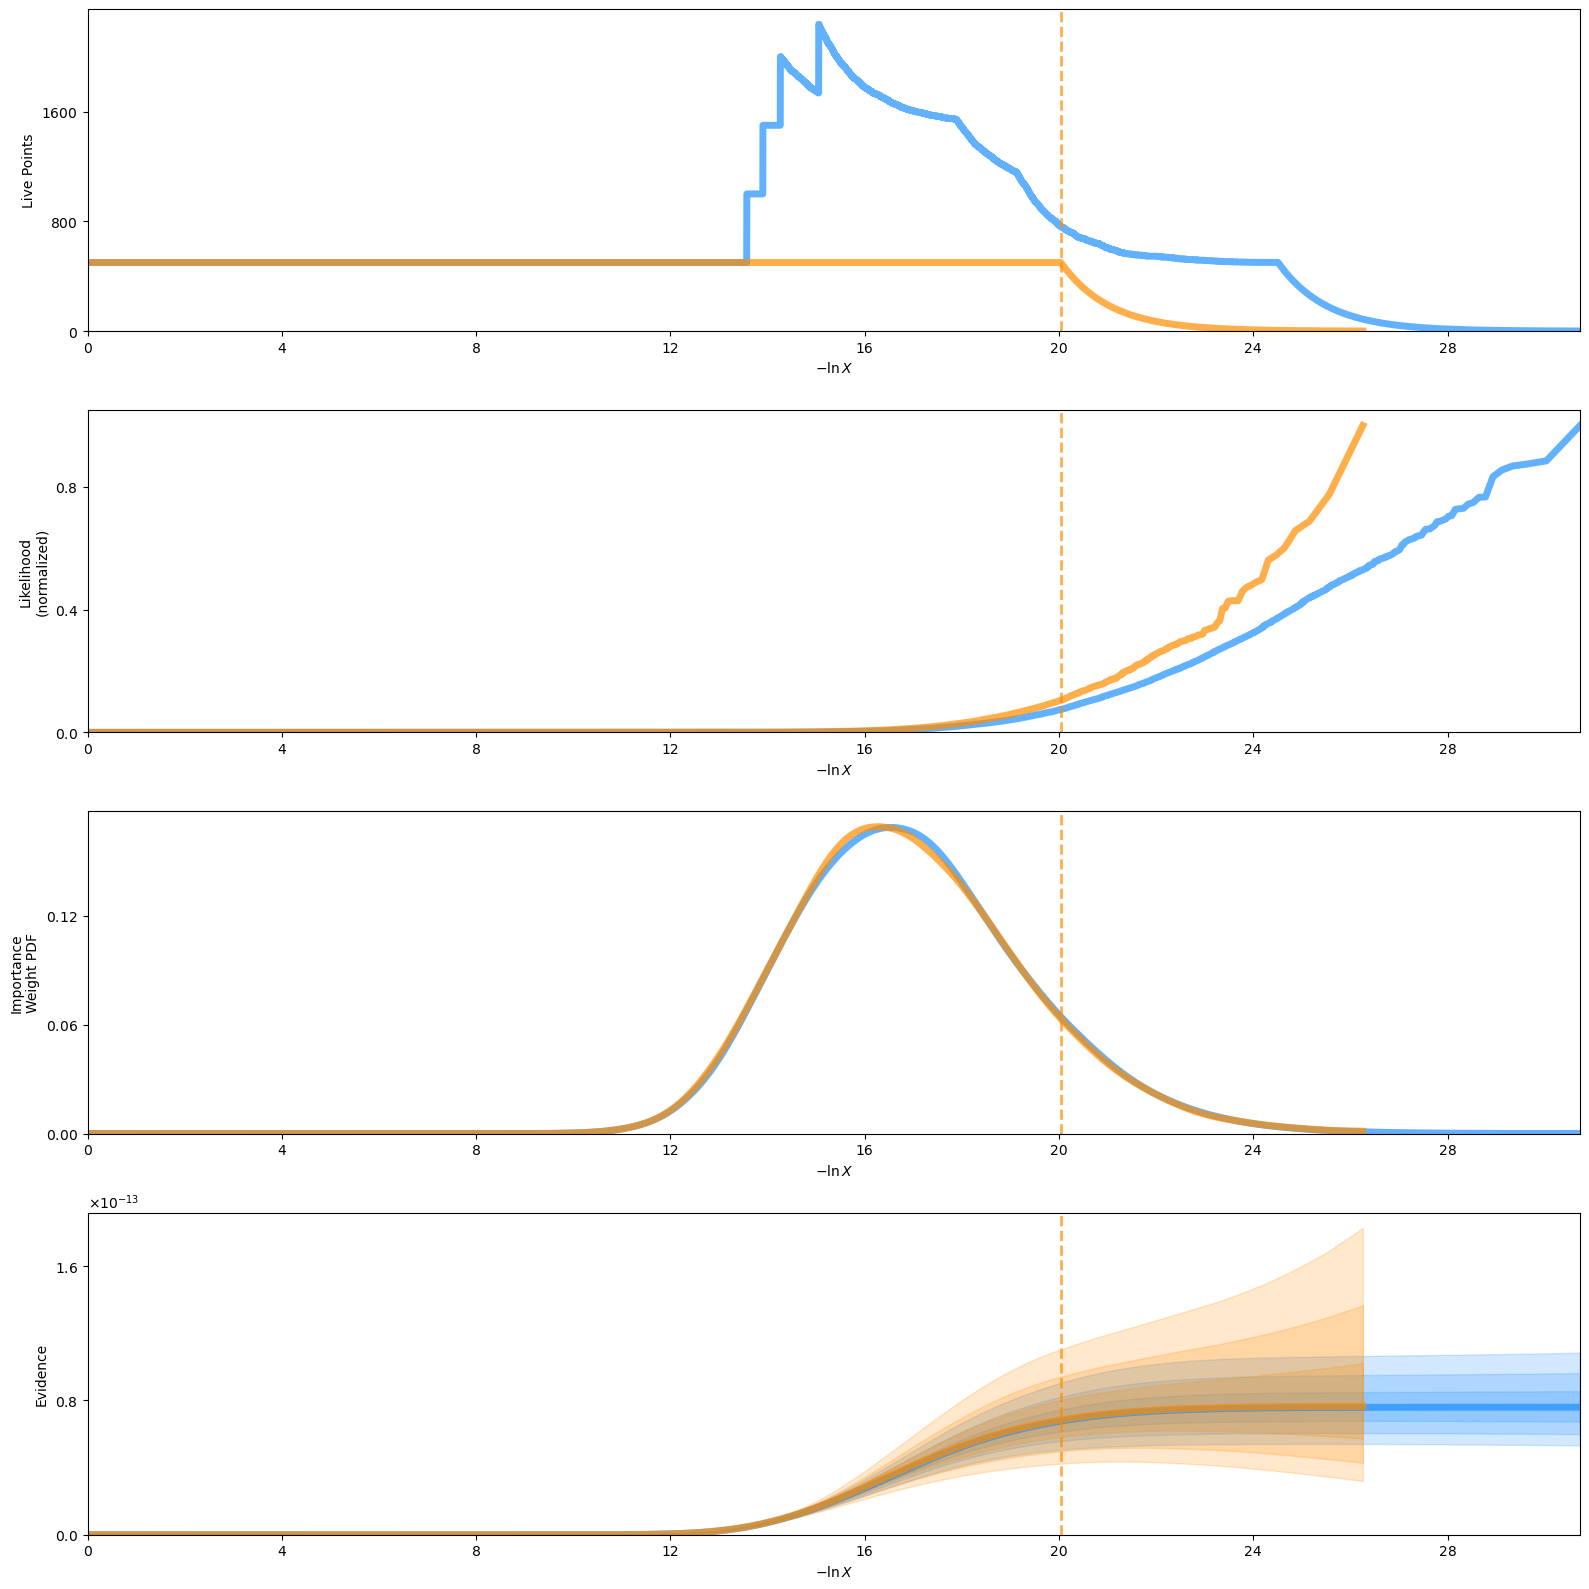

In [55]:
fig, axes = dyplot.runplot(dresults, color='dodgerblue')

fig, axes = dyplot.runplot(sresults, color='darkorange',fig=(fig, axes))

fig.tight_layout()

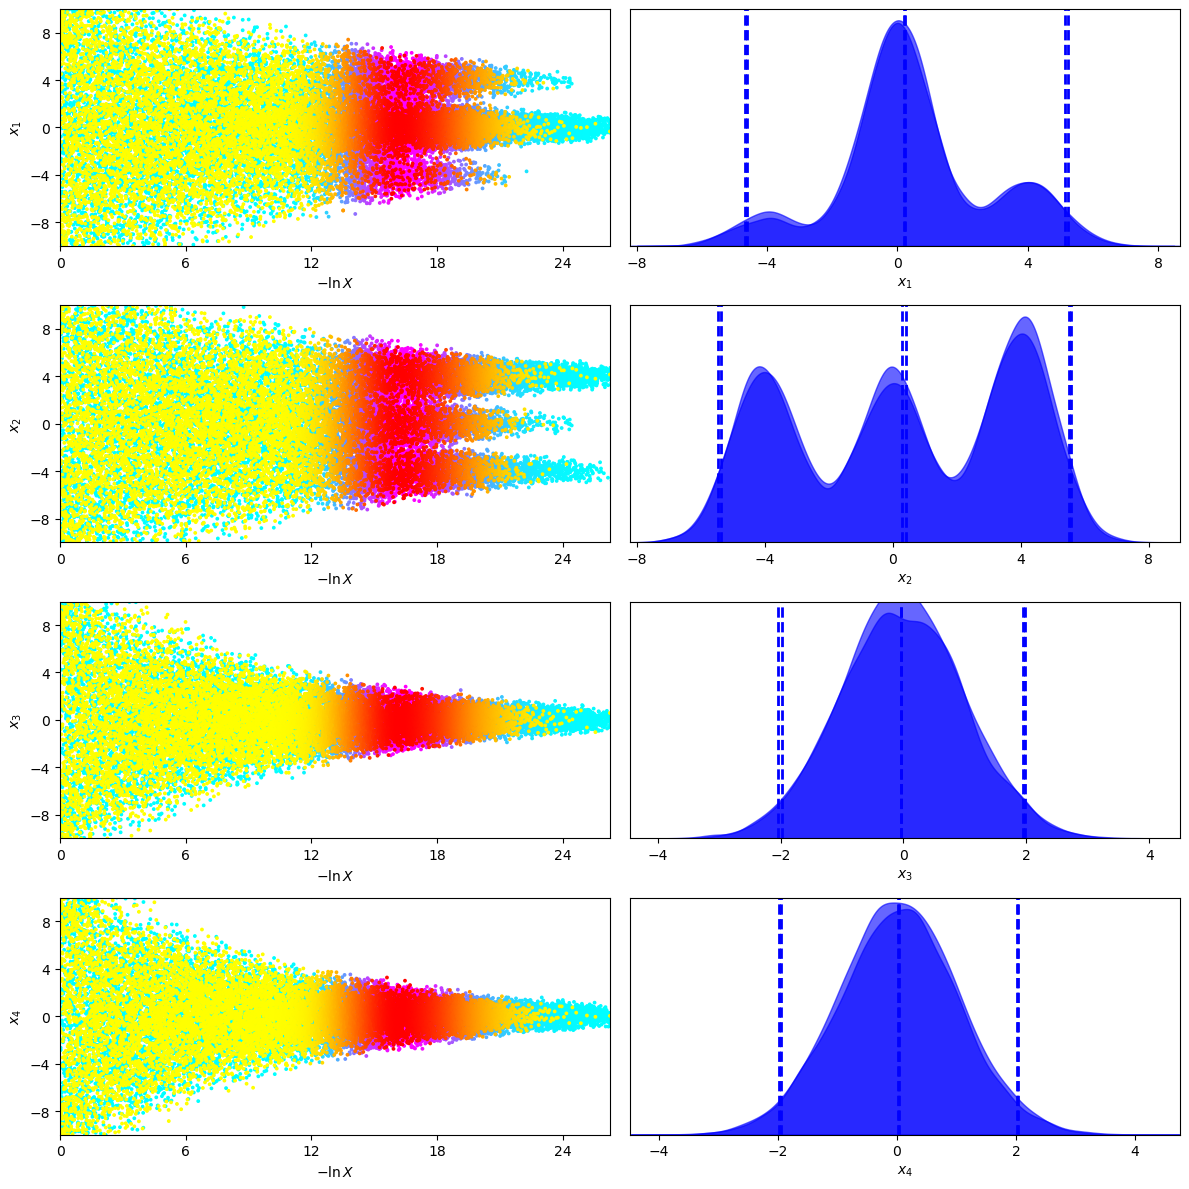

In [56]:

dims = np.arange(4) #choose first 4 dimensions to plot

fig,axes = dyplot.traceplot(dresults, dims = dims, trace_cmap ='cool');

fig,axes = dyplot.traceplot(sresults, dims = dims, trace_cmap= 'autumn_r', fig = (fig, axes));

fig.tight_layout()

plt.show()



# Sources

* Feroz F., M. P. Hobson, E. Cameron, and A. N. Pettitt. «Importance Nested Sampling and the MultiNest Algorithm», 2019, https://doi.org/10.21105/astro.1306.2144.

* Skilling John. «Nested Sampling for General Bayesian Computation», 2006, https://doi.org/10.1214/06-BA127.

* Feroz F., M. P. Hobson and M. Bridges. «MultiNest: An Efficient and Robust Bayesian Inference Tool for Cosmology and Particle Physics», 2009, https://doi.org/10.1111/j.1365-2966.2009.14548.x.

* Buchner Johannes. «A Statistical Test for Nested Sampling Algorithms», 2016, https://doi.org/10.1007/s11222-014-9512-y.

* Ashton Greg, Noam Bernstein, Johannes Buchner, Xi Chen, Gábor Csányi, Andrew Fowlie, Farhan Feroz, et al. «Nested Sampling for Physical Scientists», 2022, https://doi.org/10.1038/s43586-022-00121-x.

* Sine model example is adapted from the notebook by Johannes Buchner: https://johannesbuchner.github.io/UltraNest/index.html



## Dynesty


* Speagle Joshua S. «Dynesty: A Dynamic Nested Sampling Package for Estimating Bayesian Posteriors and Evidences», 2020 https://doi.org/10.1093/mnras/staa278.
* https://dynesty.readthedocs.io/en/stable/index.html

In [57]:
print(sampler.citations)

Code and Methods:
Speagle (2020): ui.adsabs.harvard.edu/abs/2020MNRAS.493.3132S
Koposov et al. (2023): doi.org/10.5281/zenodo.3348367

Nested Sampling:
Skilling (2004): ui.adsabs.harvard.edu/abs/2004AIPC..735..395S
Skilling (2006): projecteuclid.org/euclid.ba/1340370944


Bounding Method:
Feroz, Hobson & Bridges (2009): ui.adsabs.harvard.edu/abs/2009MNRAS.398.1601F

Sampling Method:


